## PASO 1. CARGAR ARCHIVOS Y LIBRERIAS 

In [5]:
# === PREPARACION E IMPORTACION DE LIBRERIAS ===
# Cargar todas las librerías
# Para manipulación de datos
import pandas as pd
import numpy as np

# Para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Para análisis estadístico
from scipy import stats

import math


In [6]:
# === CARGA DE ARCHIVOS ===
df_info_games = pd.read_csv('games.csv')
df_games = df_info_games

## PASO 2. PREPARA LOS DATOS ##
Observaciones previas y correcciones tipográficas y de errores como duplicados o tipo de datos incorrectos.

In [7]:
# === VISTA PREVIA Y CORRECCIÓN DE COLUMNAS Y DATOS
print(df_games.sample(6))
print(f'\nInformación del dataframe:\n')
print(df_games.info())

# Corrección de nombre de las columnas
new_col_names = []
def correct_column(df):
    for old_name in df.columns:
        name_stripped = old_name.strip()
        name_lowered = name_stripped.lower()
        name_no_spaces = name_lowered.replace(' ','_')
        new_col_names.append(name_no_spaces)
    df.columns = new_col_names
correct_column(df_games)
print('\nNombre de columnas corregidas de dataframe: ')
print(df_games.columns)

                                                  Name Platform  \
13697                              Watashi no Relaxuma       DS   
4845              Moshi Monsters: Moshlings Theme Park       DS   
10489                     Little Battlers eXperience W      3DS   
12219                          Reader Rabbit 1st Grade      Wii   
12851  Carmen Sandiego: The Secret of the Stolen Drums      PS2   
13778                                  Virtua Tennis 4       PC   

       Year_of_Release         Genre  NA_sales  EU_sales  JP_sales  \
13697           2007.0    Simulation      0.00      0.00      0.04   
4845            2012.0          Misc      0.03      0.33      0.00   
10489           2013.0  Role-Playing      0.00      0.00      0.10   
12219           2010.0          Misc      0.06      0.00      0.00   
12851           2004.0        Action      0.03      0.02      0.00   
13778           2011.0        Sports      0.00      0.03      0.00   

       Other_sales  Critic_Score User_S

In [8]:
# Procesamiento de datos por columna
print(df_games.info())
# A manera de filtro se observa que el DF contiene 16,715 entradas, así que se tomara como base para ver que columnas tienen valores ausentes
# === NAME ===
# La columna name tiene dos valores ausentes, se imprimen estos valores para proceder con el tratamiento de datos
print('\n\nValores NAN en columna name: ')
print(df_games[df_games['name'].isna() == True])
# Los valores ausentes pueden aportar para el analisis, ya que si tienen valores válidos en ventas que es lo más importante y por región
# Por lo tanto no considero que estos NaN deban deban de ser eleminados en cambio se pueden cambiar por el string 'no name info'
df_games['name'].fillna('no info', inplace=True)
print('\n\nReemplazo de los valores NAN en columna name: ')
print(df_games[df_games['name'] == 'no info'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None


Valores NAN en columna name: 
      name platform  year_of_release genre  na_sales  eu_sales  jp_sales  \
659    NaN      GEN           1993.0   NaN      1.78      0.53      0.00   
14244  NaN      GEN           1993.0   NaN      0.00

C:\Users\emili\AppData\Local\Temp\ipykernel_32940\1884420348.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_games['name'].fillna('no info', inplace=True)


In [9]:
# === YEAR OF RELEASE ===
# Pero primero se deben tratar los valores ausentes
# Considero que para la columna year_of_release primero los valores ausentes de hagan 0 y luego cambiar int
# Los valores 0 deben mostrarse como NaN para que en el analisis por año no sean tomados en cuenta
df_games['year_of_release'] = df_games['year_of_release'].replace(0, np.nan).astype('Int64')
print('\n\nMuestra de columna year of release: ')
print(df_games['year_of_release'].sample(5))
# Así para los valores ausentes se relacionaran con 0, es decir que no se tiene información con su fecha de lanzamiento




Muestra de columna year of release: 
7000     2007
16243    2010
13015    2011
3642     2002
1415     1998
Name: year_of_release, dtype: Int64


In [10]:
# === GENRE ===
# Se procedera de la misma manera que con la columna name
print('Valores NAN en columna genre: ')
print(df_games[df_games['genre'].isna() == True])
# Son los mismas entradas que para los valores ausentes en la columna name
# Por lo que se corrige de la misma manera
df_games['genre'].fillna('no info', inplace=True)
print('\n\nReemplazo de los valores NAN en columna genre: ')
print(df_games[df_games['genre'] == 'no info'])

Valores NAN en columna genre: 
          name platform  year_of_release genre  na_sales  eu_sales  jp_sales  \
659    no info      GEN             1993   NaN      1.78      0.53      0.00   
14244  no info      GEN             1993   NaN      0.00      0.00      0.03   

       other_sales  critic_score user_score rating  
659           0.08           NaN        NaN    NaN  
14244         0.00           NaN        NaN    NaN  


Reemplazo de los valores NAN en columna genre: 
          name platform  year_of_release    genre  na_sales  eu_sales  \
659    no info      GEN             1993  no info      1.78      0.53   
14244  no info      GEN             1993  no info      0.00      0.00   

       jp_sales  other_sales  critic_score user_score rating  
659        0.00         0.08           NaN        NaN    NaN  
14244      0.03         0.00           NaN        NaN    NaN  


C:\Users\emili\AppData\Local\Temp\ipykernel_32940\2281014638.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_games['genre'].fillna('no info', inplace=True)


In [11]:
# === CRITIC SCORE ===
# Analisis de los datos e interpretación
print(df_games['critic_score'].sample(10))
# Viendo los datos considero que no es necesario reemplazar ni eliminar los valores asuentes
# Ya que al ser valores numericos no conviene reemplazarlos por 0 y la mayoría de metodos para el analisis no toma en cuento estos valores
# Por lo que no habra cambios en esta columna

14456     NaN
7727      NaN
16510    82.0
2346     80.0
11702     NaN
12757    70.0
16535     NaN
1592     64.0
11321     NaN
9248      NaN
Name: critic_score, dtype: float64


In [12]:
# === USER SCORE ===
# Analisis de los datos e interpretación
print(df_games['user_score'].sample(10))
# Por los visto la escala es de 0 - 10.0, los valores ausentes no represantan un valor y asignarlos a 0 podría sesgar el analisis de esta columna 
# Tambien hay entrada que contienen tbd según la información dada previamente significa "por determinar" 
# Considero que los valores tbd deberían ser considerados como NaN ya que no aportan un valor numerico a los analisis 
df_games['user_score'] = df_games['user_score'].replace('tbd', np.nan).astype('float')
print('\nMuestra de valores cambiados: ')
print(df_games['user_score'].sample(5))

14066    NaN
8545     6.3
16703    NaN
7342     tbd
268      9.3
7461     7.1
14672    tbd
3543     8.6
5309     4.4
2435     7.4
Name: user_score, dtype: object

Muestra de valores cambiados: 
15755    NaN
1338     7.6
14727    6.2
9130     NaN
9213     8.0
Name: user_score, dtype: float64


In [13]:
# === RATING ===
# Observación de los datos y datos asuentes
print('Muestra de la columna rating: ')
print(df_games['rating'].sample(5))
print('\n\nMuestra de datos ausentes de la columna rating:')
print(df_games[df_games['rating'].isna() == True].sample(5))
# No parece haber algún patron en los datos ausentes por lo que los valores se quedaran intactos
# En caso de un analisis referente a este se podrán eliminar los valores ausentes para el dataframe especifico

Muestra de la columna rating: 
7223      M
9785      M
6451    NaN
2204    NaN
3976      E
Name: rating, dtype: object


Muestra de datos ausentes de la columna rating:
                                                   name platform  \
7487   J-League Pro Soccer Club o Tsukurou! 7 Euro Plus      PSP   
11402                      Kamen Rider: Travelers Senki      3DS   
1204                       007: The World is not Enough      N64   
16002                  Berserk and the Band of the Hawk      PSV   
7929                   Thomas the Tank Engine & Friends      GBA   

       year_of_release      genre  na_sales  eu_sales  jp_sales  other_sales  \
7487              2011     Sports      0.00      0.00      0.21         0.00   
11402             2013     Action      0.00      0.00      0.08         0.00   
1204              2000     Action      1.13      0.38      0.02         0.03   
16002             2016     Action      0.00      0.00      0.02         0.00   
7929              2004

In [14]:
# Busqueda de duplicados
# Para este dataframe considero que solo puede ser considerado duplicado una entrada en caso de que 
# tengan la misma informacion en todas las columnas
# Ver si hay duplicados
print("¿Hay duplicados?", df_games.duplicated().any())
print("Número de duplicados:", df_games.duplicated().sum())
# Por lo tanto no habrá correcciónes en este apartado

¿Hay duplicados? False
Número de duplicados: 0


In [15]:
# === VENTAS TOTALES ===
# Crear una columna con las ventas totales
df_games['total_sales'] = (df_games['na_sales']+
                          df_games['eu_sales']+
                          df_games['jp_sales']+
                          df_games['other_sales'])
game_sales = ['jp_sales', 'na_sales', 'eu_sales', 'other_sales', 'total_sales']
print(df_games[game_sales].sample(5))

       jp_sales  na_sales  eu_sales  other_sales  total_sales
7196       0.00      0.20      0.00         0.02         0.22
9204       0.00      0.00      0.11         0.02         0.13
4151       0.47      0.00      0.00         0.00         0.47
5549       0.00      0.23      0.09         0.01         0.33
11983      0.07      0.00      0.00         0.00         0.07


## PASO 3. ANALIZA LOS DATOS ##

### 3.1. Juegos lanzados por año: ##

   year_of_release  released_games
0             1980               9
1             1981              46
2             1982              36
3             1983              17
4             1984              14


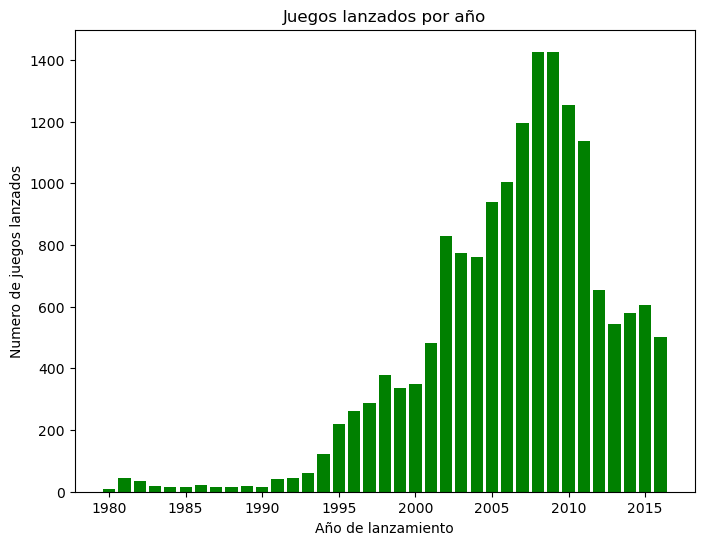

In [16]:
# Numero de juegos lanzados por año
games_per_year = df_games.groupby('year_of_release')['name'].count().reset_index().rename(columns={'name':'released_games'})
print(games_per_year.head())

# Gráfico de barras
plt.figure(figsize=(8, 6))
año = games_per_year['year_of_release']
juegos_lanzados = games_per_year['released_games']
plt.bar(año, juegos_lanzados, color = 'green')
plt.title('Juegos lanzados por año')
plt.ylabel('Numero de juegos lanzados')
plt.xlabel('Año de lanzamiento')
plt.show()


Al obervar la gráfica anterior durante los años 1980 al 1995 no se tienen registros significativos de juegos lanzados, por lo que podemos asumir que para nuestro analisis solo se usaran los juegos lanzados a partir de 1995.

### 3.2. Ventas por plataforma:

   platform  total_sales
10      N64       218.68
24     TG16         0.16
6       GBA       317.85
26      Wii       907.51
22      SCD         1.86
   platform  total_sales
6       GBA       317.85
11      NES       251.05
10      N64       218.68
23     SNES       200.04
29       XB       257.74


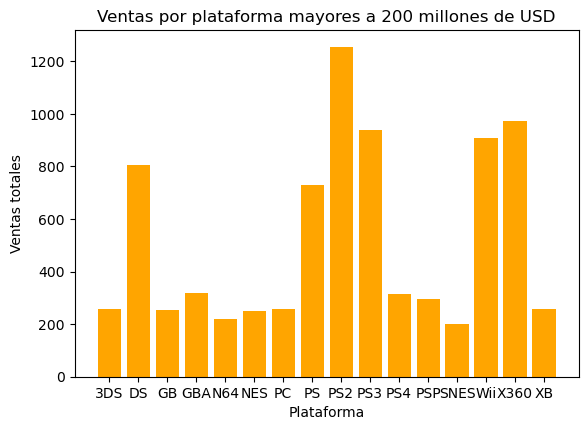

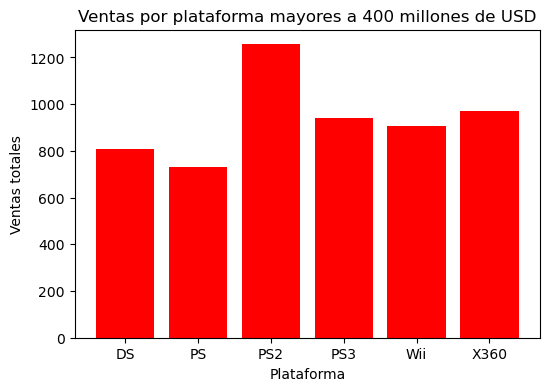

In [17]:
# Variacion de las ventas entre plataformas
platform_sales = df_games.groupby('platform')['total_sales'].sum().reset_index()
print(platform_sales.sample(5))

# Elegir las plataformas con las mayores ventas totales
top_sales_platform = platform_sales[platform_sales['total_sales'] >= 200]
print(top_sales_platform.sample(5))
# Gráfico de barras
plt.figure(figsize=(6.5, 4.5))
ventas = top_sales_platform['total_sales']
plataforma = top_sales_platform['platform']
plt.bar(plataforma, ventas, color='orange')
plt.title('Ventas por plataforma mayores a 200 millones de USD')
plt.ylabel('Ventas totales')
plt.xlabel('Plataforma')
plt.show()
# Viendo la gráfica resultante podemos filtrar la cantidad de ventas a 400 para obtener las plataformas con más ventas de la historia
most_sales_platform = platform_sales[platform_sales['total_sales'] >= 400]
plt.figure(figsize=(6, 4))
ventas = most_sales_platform['total_sales']
plataforma = most_sales_platform['platform']
plt.bar(plataforma, ventas, color='red')
plt.title('Ventas por plataforma mayores a 400 millones de USD')
plt.ylabel('Ventas totales')
plt.xlabel('Plataforma')
plt.show()
# Para estoy estoy suponiendo que las unidades de las columnas de venta estan en millones de USD


    year_of_release platform  total_sales
0              1985       DS         0.02
1              1994       PS         6.03
2              1995       PS        35.96
3              1996       PS        94.70
4              1997       PS       136.17
..              ...      ...          ...
62             2015      Wii         1.14
63             2015     X360        11.96
64             2016      PS3         3.60
65             2016      Wii         0.18
66             2016     X360         1.52

[67 rows x 3 columns]


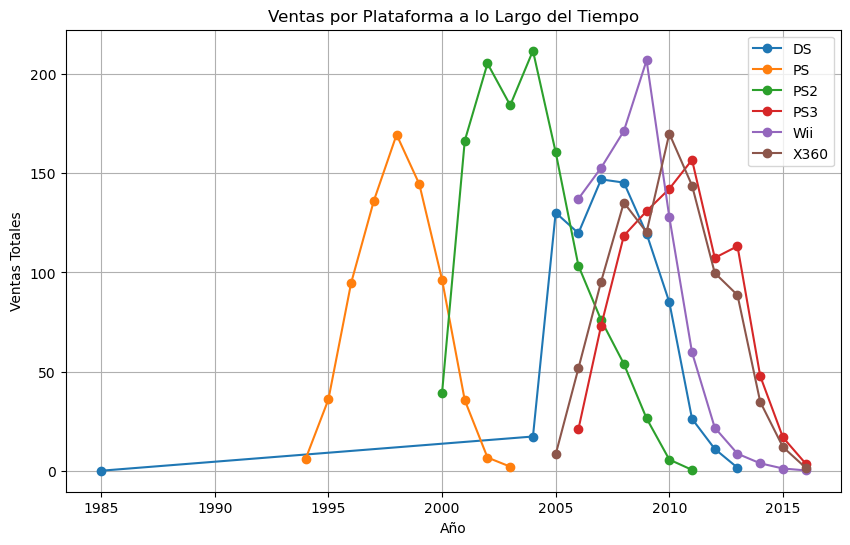

In [18]:
# Construye una distribución basada en los datos de cada año
# Ya se tienen el top de plataformas entonces solo es crear un df con los demás datos en base a la plataforma
top_platform = df_games[df_games['platform'].isin(most_sales_platform['platform'])]
top_platform_per_year = top_platform.groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index()
print(top_platform_per_year)
plt.figure(figsize=(10, 6))
for platform in most_sales_platform['platform']:
    data = top_platform_per_year[top_platform_per_year['platform'] == platform]
    plt.plot(data['year_of_release'], data['total_sales'], 
             marker='o', label=platform)

plt.title('Ventas por Plataforma a lo Largo del Tiempo')
plt.xlabel('Año')
plt.ylabel('Ventas Totales')
plt.legend()
plt.grid(True)
plt.show()


Considero que el juego de nintendo DS lanzado en 1985 puede interferir con el análisis de los datos, la consola fue lanzada en 2004 por lo que es ilógico que ya exisitiera un juego desde 1985. Buscando en la web, efectivamente el juego fue lanzado en 1985, sin embargo eliminare esa entrada ya que en mi punto de vista afecta más agregarlo. 

Empty DataFrame
Columns: [name, platform, year_of_release, genre, na_sales, eu_sales, jp_sales, other_sales, critic_score, user_score, rating, total_sales]
Index: []
    year_of_release platform  total_sales
0              1994       PS         6.03
1              1995       PS        35.96
2              1996       PS        94.70
3              1997       PS       136.17
4              1998       PS       169.49
..              ...      ...          ...
61             2015      Wii         1.14
62             2015     X360        11.96
63             2016      PS3         3.60
64             2016      Wii         0.18
65             2016     X360         1.52

[66 rows x 3 columns]


C:\Users\emili\AppData\Local\Temp\ipykernel_32940\1258102758.py:2: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  df_games.query("year_of_release == 1985 and platform == 'DS'")


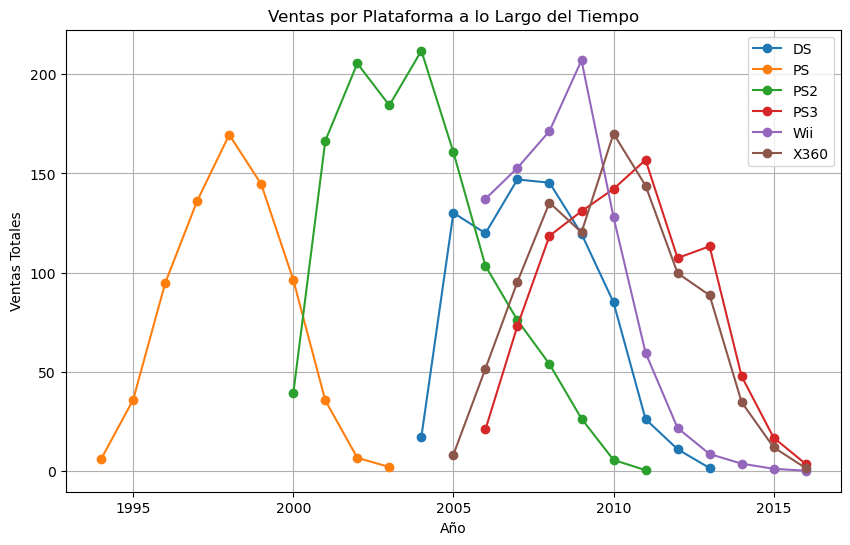

In [19]:
# print(df_games[(df_games['year_of_release'] == 1985) & (df_games['platform'] == 'DS')])
df_games.query("year_of_release == 1985 and platform == 'DS'")
remove_name = 'Strongest Tokyo University Shogi DS'
df_games.drop(df_games[df_games['name'] == remove_name].index, inplace=True)
print(df_games.query(f'name == "{remove_name}"'))

# Volvemos a ejecutar el mismo código de la anterior sección con el df modificado
top_platform = df_games[df_games['platform'].isin(most_sales_platform['platform'])]
top_platform_per_year = top_platform.groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index()
print(top_platform_per_year)
plt.figure(figsize=(10, 6))
for platform in most_sales_platform['platform']:
    data = top_platform_per_year[top_platform_per_year['platform'] == platform]
    plt.plot(data['year_of_release'], data['total_sales'], 
             marker='o', label=platform)

plt.title('Ventas por Plataforma a lo Largo del Tiempo')
plt.xlabel('Año')
plt.ylabel('Ventas Totales')
plt.legend()
plt.grid(True)
plt.show()



### ¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer? ###

En la representación gráfica se muestra que la mayoría de plataformas duran 10 años desde su lanzamiento, en cuanto a la aparición de nuevas consolas en la representación gráfica se ve una variación diferente entre cada plataforma.


Determina para qué período debes tomar datos. Para hacerlo mira tus respuestas a las preguntas anteriores. Los datos deberían permitirte construir un modelo para 2017.

Respuesta: Teniendo en cuenta que las plataformas suelen tener 10 años de vida, sería tomar las plataformas que se encuentran por lo menos 2010 hasta 2016, para obtener plataformas en la que se encuentre a la mitad de su vida ultil que es cuando más ventas suelen generar y tomar nues plataformas que estan en crecimiento, según los patrones observados.


In [20]:
# Filtrado del DF de acuerdo al año de lanzamiento >= 2010
df_games_projection = df_games[df_games['year_of_release'] >= 2010]
print('Muestra del DF filtrado para juegos lanzados después de 2010: ')
print(df_games_projection.sample(6))

Muestra del DF filtrado para juegos lanzados después de 2010: 
                                    name platform  year_of_release  \
10854                    Kung Fu Panda 2      PS3             2011   
7453        Prison Break: The Conspiracy     X360             2010   
15563                 Resident Evil 5 HD     XOne             2016   
4138                 Alice in Wonderland       DS             2010   
15053  Diabolik Lovers: Vandead Carnival      PSV             2014   
10540    Inazuma Eleven GO Strikers 2013      Wii             2012   

              genre  na_sales  eu_sales  jp_sales  other_sales  critic_score  \
10854        Action      0.04      0.04      0.00         0.01           NaN   
7453         Action      0.07      0.11      0.00         0.02          40.0   
15563        Action      0.02      0.00      0.00         0.00           NaN   
4138      Adventure      0.25      0.17      0.00         0.04          78.0   
15053        Action      0.00      0.00      0

### ¿Qué plataformas son líderes en ventas? ¿Cuáles crecen y cuáles se reducen? ###

Plataformas líderes en ventas: 
  platform  total_sales
0      PS3       587.74
1     X360       550.41
2      PS4       314.14
3      3DS       257.81
4      Wii       222.97
5     XOne       159.32
6       DS       123.75
7       PC       121.96
8     WiiU        82.19
9      PSP        64.05
['PS3' 'X360' 'PS4' '3DS' 'Wii' 'XOne' 'DS' 'PC' 'WiiU' 'PSP' 'PSV' 'PS2']


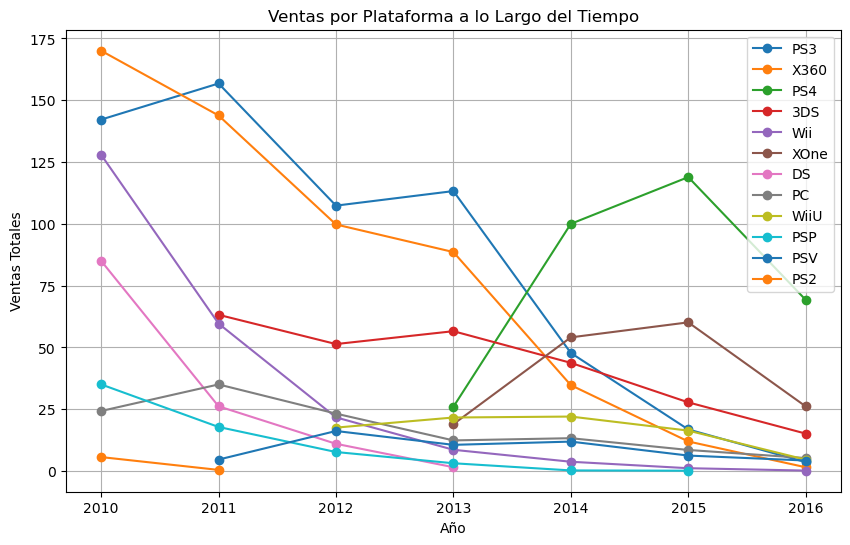

In [21]:
# Calcular ventas totales por plataforma
ventas_por_plataforma = df_games_projection.groupby(['platform'])['total_sales'].sum().sort_values(ascending=False).reset_index()

# Ver las top 5-10 plataformas
print('Plataformas líderes en ventas: ')
print(ventas_por_plataforma.head(10))

# Para mostrar cuales crecen y cuales de reducen opte por hacer un gráfico de líneas 
nuevas_plataformas = ventas_por_plataforma['platform'].unique()
print(nuevas_plataformas)
ventas_por_plataforma_año = df_games_projection.groupby(['platform', 'year_of_release'])['total_sales'].sum().reset_index()

plt.figure(figsize=(10, 6))
for platform in nuevas_plataformas:
    data = ventas_por_plataforma_año[ventas_por_plataforma_año['platform'] == platform]
    plt.plot(data['year_of_release'], data['total_sales'], 
             marker='o', label=platform)

plt.title('Ventas por Plataforma a lo Largo del Tiempo')
plt.xlabel('Año')
plt.ylabel('Ventas Totales')
plt.legend()
plt.grid(True)
plt.show()

Parece que las plataformas empiezan a crecer son XONE y PS4 las demás tienden a disminuir, o mentenerse como 3DS, PC, WiiU, PSV. Las plataformas más seguras para efectuar una campaña exitosa son XONE y PS4, en caso de querer abarcar más plataformas pueden ser 3DS, PC y WiiU.

In [22]:
#  Por lo tanto filtraremos de nuevo el dataframe a las siguientes plataforas
# XONE, PS4, PC, 3DS y WiiU
name_of_platform = ['XOne', 'PS4', 'PC', '3DS','WiiU']
df_projection = df_games_projection[df_games_projection['platform'].isin(name_of_platform)]

print(df_projection.sample(5))

                                            name platform  year_of_release  \
1552  Pokemon Mystery Dungeon: Gates to Infinity      3DS             2012   
7821                  SpongeBob SquigglePants 3D      3DS             2011   
7324             Magician's Quest: Town of Magic      3DS             2012   
6601                        Final Fantasy Type-0     XOne             2015   
3186                                   Far Cry 4       PC             2014   

             genre  na_sales  eu_sales  jp_sales  other_sales  critic_score  \
1552  Role-Playing      0.44      0.29      0.47         0.07          59.0   
7821          Misc      0.13      0.05      0.00         0.02          64.0   
7324    Simulation      0.00      0.00      0.21         0.00           NaN   
6601  Role-Playing      0.16      0.07      0.00         0.02           NaN   
3186       Shooter      0.15      0.44      0.00         0.04          80.0   

      user_score rating  total_sales  
1552         6.3 

#### Crea un diagrama de caja para las ventas globales de todos los juegos, desglosados por plataforma. ¿Son significativas las diferencias en las ventas? ¿Qué sucede con las ventas promedio en varias plataformas? Describe tus hallazgos. ####

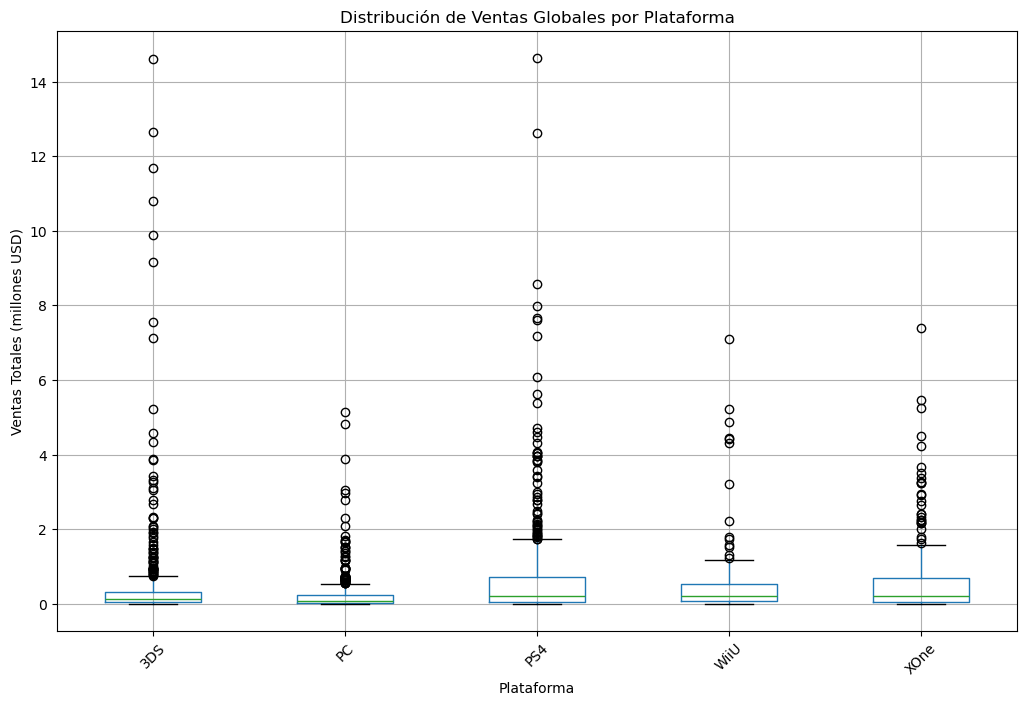

Estadísticas de ventas por plataforma:
          count      mean       std   min   25%   50%     75%    max
platform                                                            
3DS       512.0  0.503535  1.441271  0.01  0.05  0.12  0.3325  14.60
PC        479.0  0.254614  0.530874  0.01  0.03  0.08  0.2300   5.14
PS4       392.0  0.801378  1.609456  0.01  0.06  0.20  0.7300  14.63
WiiU      147.0  0.559116  1.058836  0.01  0.08  0.22  0.5250   7.09
XOne      247.0  0.645020  1.036139  0.01  0.06  0.22  0.6850   7.39

Ventas promedio por plataforma:
platform
PS4     0.801378
XOne    0.645020
WiiU    0.559116
3DS     0.503535
PC      0.254614
Name: total_sales, dtype: float64


In [23]:
# Boxplot
plt.figure(figsize=(12, 8))
df_projection.boxplot(column='total_sales', by='platform', ax=plt.gca())
plt.title('Distribución de Ventas Globales por Plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Ventas Totales (millones USD)')
plt.suptitle('')  
plt.xticks(rotation=45)
plt.show()
# Estadísticas descriptivas por plataforma
print("Estadísticas de ventas por plataforma:")
print(df_projection.groupby('platform')['total_sales'].describe())

# Ventas promedio por plataforma
ventas_promedio = df_projection.groupby('platform')['total_sales'].mean().sort_values(ascending=False)
print("\nVentas promedio por plataforma:")
print(ventas_promedio)



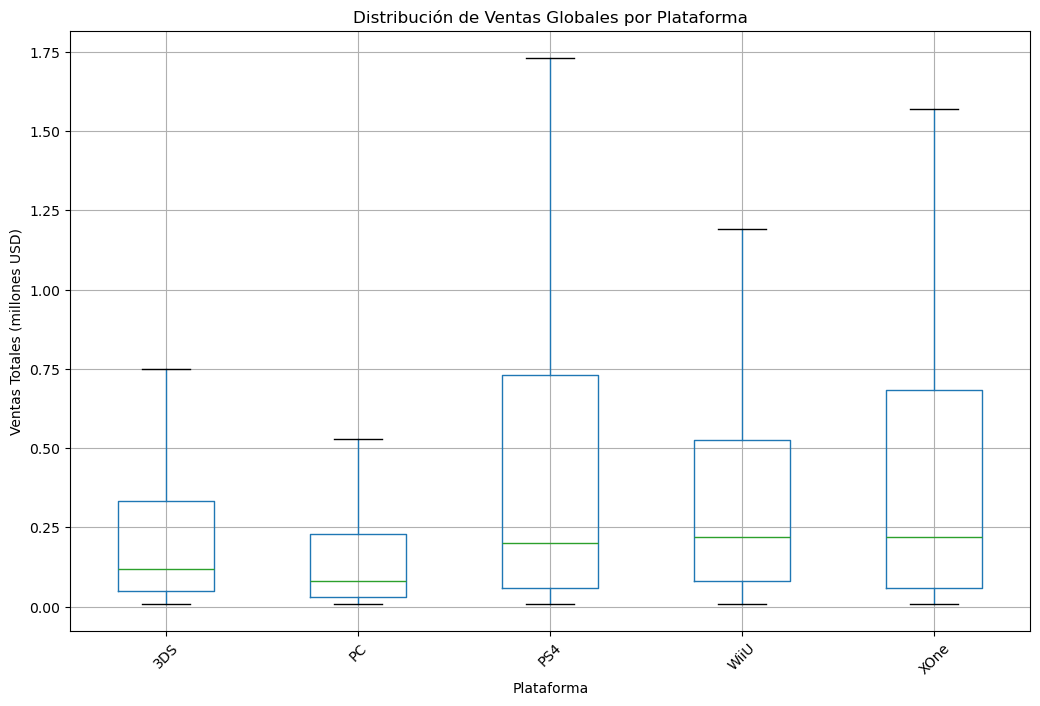

In [24]:
# Boxplot
plt.figure(figsize=(12, 8))
df_projection.boxplot(column='total_sales', by='platform', ax=plt.gca(), showfliers = False)
plt.title('Distribución de Ventas Globales por Plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Ventas Totales (millones USD)')
plt.suptitle('')  
plt.xticks(rotation=45)
plt.show()


1. Diferencias significativas:
- ¿Qué plataforma tiene la mediana más alta? \
Las 5 medianas se encuentran en un rango similiar, por que no hay diferencia ni una mayor que otra.

- ¿Cuál tiene mayor variabilidad en las ventas? \
La plataforma PS4 cuenta con una mayor variabilidad en sus ventas, aunque tampoco es demasiado grande la diferencia en el gráfico, pero cabe aclarar que esta medido en millones de dolares, por lo que una unidad representaria un millon de dolares más o menos.
2. Ventas promedio:
- Calcula el promedio por plataforma\
La media es mayor que la mediana en todos los casos como se observa en los datos estadísticos (mean vs 50%).
En cuanto a los valores observamos que PS4 tiene una mayor media en cuanto a ventas, y la más baja es PC. La plataforma de PS4 y 3DS tienen juegos que alcanzaron ventas muy altas en comparación con los demás juegos alcanzado un valor máximo de 14.6, podemos considerarlo como valores atípicos ya que se salen por mucho de la media de ventas.

#### Mira cómo las reseñas de usuarios y profesionales afectan las ventas de una plataforma popular (PS4). Crea un gráfico de dispersión y calcula la correlación entre las reseñas y las ventas. Saca conclusiones. ####

Datos disponibles para PS4: 239 juegos
                               name  critic_score  user_score  total_sales
42               Grand Theft Auto V          97.0         8.3        12.62
77                          FIFA 16          82.0         4.3         8.58
92   Call of Duty: Advanced Warfare          83.0         5.7         7.66
94                          FIFA 17          85.0         5.0         7.60
105                       Fallout 4          87.0         6.5         7.17


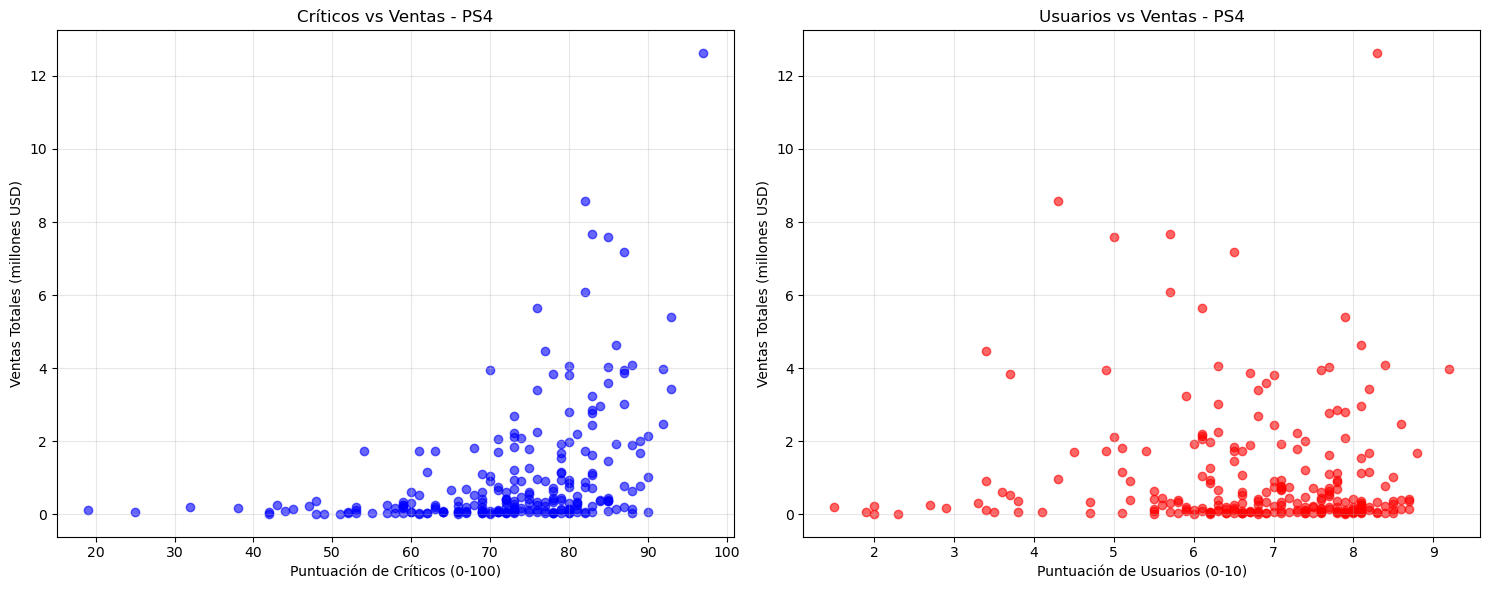


Top 10 juegos por ventas:
                                       name  critic_score  total_sales
42                       Grand Theft Auto V          97.0        12.62
77                                  FIFA 16          82.0         8.58
92           Call of Duty: Advanced Warfare          83.0         7.66
94                                  FIFA 17          85.0         7.60
105                               Fallout 4          87.0         7.17
143                                 FIFA 15          82.0         6.08
154                                 Destiny          76.0         5.64
171              Uncharted 4: A Thief's End          93.0         5.39
231  Uncharted: The Nathan Drake Collection          86.0         4.62
245          Call of Duty: Infinite Warfare          77.0         4.47

Correlación críticos-ventas: 0.404

Correlación usuarios-ventas: -0.031


In [25]:
plataforma = 'PS4'
datos_plataforma = df_projection[df_projection['platform'] == plataforma].copy()

# Eliminar valores NaN para el análisis de correlación
datos_limpios = datos_plataforma.dropna(subset=['critic_score', 'user_score', 'rating', 'total_sales'])

print(f"Datos disponibles para {plataforma}: {len(datos_limpios)} juegos")
print(datos_limpios[['name', 'critic_score', 'user_score', 'total_sales']].head())

# Gráfico 1: Critic Score vs Ventas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.scatter(datos_limpios['critic_score'], datos_limpios['total_sales'], 
           alpha=0.6, color='blue')
ax1.set_xlabel('Puntuación de Críticos (0-100)')
ax1.set_ylabel('Ventas Totales (millones USD)')
ax1.set_title(f'Críticos vs Ventas - {plataforma}')
ax1.grid(True, alpha=0.3)
# Gráfico 2: User Score vs Ventas
ax2.scatter(datos_limpios['user_score'], datos_limpios['total_sales'], 
           alpha=0.6, color='red')
ax2.set_xlabel('Puntuación de Usuarios (0-10)')
ax2.set_ylabel('Ventas Totales (millones USD)')
ax2.set_title(f'Usuarios vs Ventas - {plataforma}')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

top_ventas = datos_limpios.nlargest(10, 'total_sales')[['name', 'critic_score', 'total_sales']]
print("\nTop 10 juegos por ventas:")
print(top_ventas)

correlacion, p_valor = stats.pearsonr(datos_limpios['critic_score'], datos_limpios['total_sales'])
print(f"\nCorrelación críticos-ventas: {correlacion:.3f}")
correlacion_2 , p_valor = stats.pearsonr(datos_limpios['user_score'], datos_limpios['total_sales'])
print(f"\nCorrelación usuarios-ventas: {correlacion_2:.3f}")

Analizando los valores obtenidos y observando el gráfico podemos ver una relación entre la puntuación de críticos y las ventas, tendiendo una dependencia lineal positiva, es decir a mayor puntuación de críticos mayores ventas, el coeficiente de corelación es de 0.406 dando por hecho que tiene correlación moderada, es clara pero no puede ser un modelo predecible a seguir, ya que puede tener sus fallas. \
En cuanto a la opinion de usuarios el coeficiente de correlación es cercano a 0, por lo que no existe una dependencia clara entre la puntuación de usuarios contra las ventas.

#### Teniendo en cuenta tus conclusiones compara las ventas de los mismos juegos en otras plataformas. ####

No estoy comletamente seguro de cuales juegos tomar para esta comparativa, tomaré los juegos obtenidos del dataframe datos_limpios como base para comparar las ventas de juegos por plataforma. Así que tomaré como juego válido aquel que se encuentre en 3 o más plataformas.

Juegos disponibles en más plataformas:
name
Lego Batman 3: Beyond Gotham    5
Terraria                        5
LEGO Marvel Super Heroes        5
LEGO The Hobbit                 5
The LEGO Movie Videogame        5
LEGO Jurassic World             5
Skylanders: Trap Team           4
LEGO Marvel's Avengers          4
Skylanders SWAP Force           4
Angry Birds Star Wars           4
Name: platform, dtype: int64


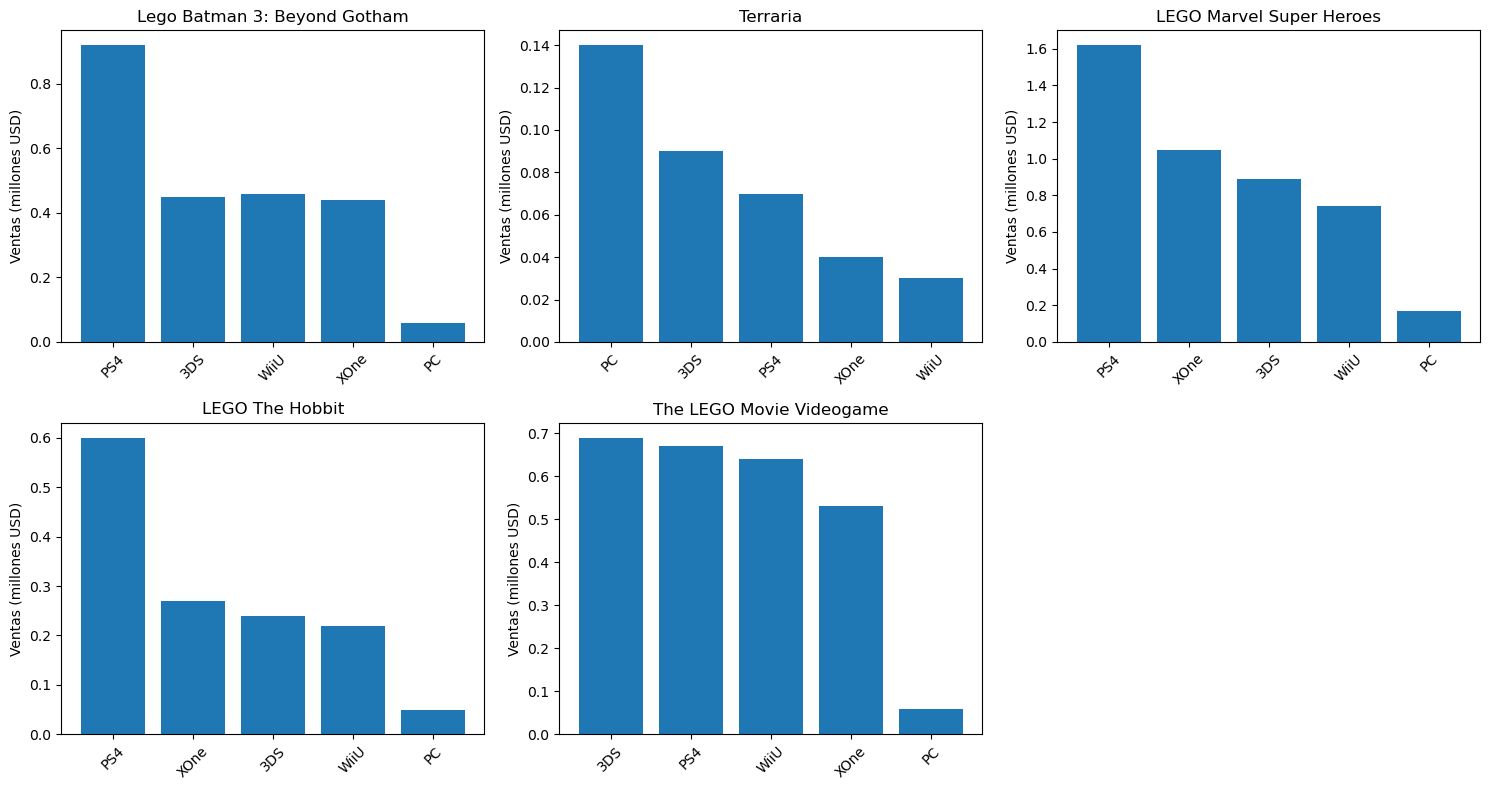

In [26]:
nombre_juegos = datos_limpios['name'].unique()

juegos_multiplataforma = df_projection[df_projection['name'].isin(nombre_juegos)]
juegos_por_plataforma = juegos_multiplataforma.groupby('name')['platform'].count().sort_values(ascending=False)
print("Juegos disponibles en más plataformas:")
print(juegos_por_plataforma.head(10))

juegos_populares = juegos_por_plataforma[juegos_por_plataforma >= 3].index
# print(f'\n{juegos_populares}')
comparacion_ventas = juegos_multiplataforma[juegos_multiplataforma['name'].isin(juegos_populares)]
# Gráfico de barras agrupadas para comparar ventas
plt.figure(figsize=(15, 8))
for i, juego in enumerate(juegos_populares[:5]):  
    # print(f'\n{i}')
    # print(juego)
    datos_juego = comparacion_ventas[comparacion_ventas['name'] == juego]
    plt.subplot(2, 3, i+1)
    plt.bar(datos_juego['platform'], datos_juego['total_sales'])
    plt.title(f'{juego}')
    plt.ylabel('Ventas (millones USD)')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Los juegos multiplataforma con mayores ventas son los de LEGO, es un patrón curioso y que no esperaba ver.

#### Echa un vistazo a la distribución general de los juegos por género. ¿Qué se puede decir de los géneros más rentables? ¿Puedes generalizar acerca de los géneros con ventas altas y bajas? ####

In [27]:
# Distrubución por género
ventas_por_genero = df_projection.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
juegos_por_genero = df_projection.groupby('genre')['name'].count().sort_values(ascending=False)

print('\nAnálisis completo por género:')
analisis_generos = pd.DataFrame({
    'cantidad_juegos': juegos_por_genero,
    'ventas_totales': ventas_por_genero,
    'ventas_promedio': df_projection.groupby('genre')['total_sales'].mean(),
    'desviacion_estandar': df_projection.groupby('genre')['total_sales'].std()
}).sort_values('ventas_totales', ascending=False)
# Calcular coeficiente de variación (riesgo)
analisis_generos['coef_variacion'] = analisis_generos['desviacion_estandar'] / analisis_generos['ventas_promedio']

print("\nAnálisis completo por género:")
print(analisis_generos.round(3))


Análisis completo por género:

Análisis completo por género:
              cantidad_juegos  ventas_totales  ventas_promedio  \
genre                                                            
Action                    584          231.96            0.397   
Shooter                   169          181.08            1.071   
Role-Playing              212          155.13            0.732   
Sports                    146           98.82            0.677   
Platform                   68           63.00            0.926   
Racing                     85           47.37            0.557   
Simulation                 95           44.67            0.470   
Misc                      126           39.98            0.317   
Fighting                   48           28.06            0.585   
Strategy                   89           21.75            0.244   
Adventure                 115           16.04            0.139   
Puzzle                     40            7.56            0.189   

             

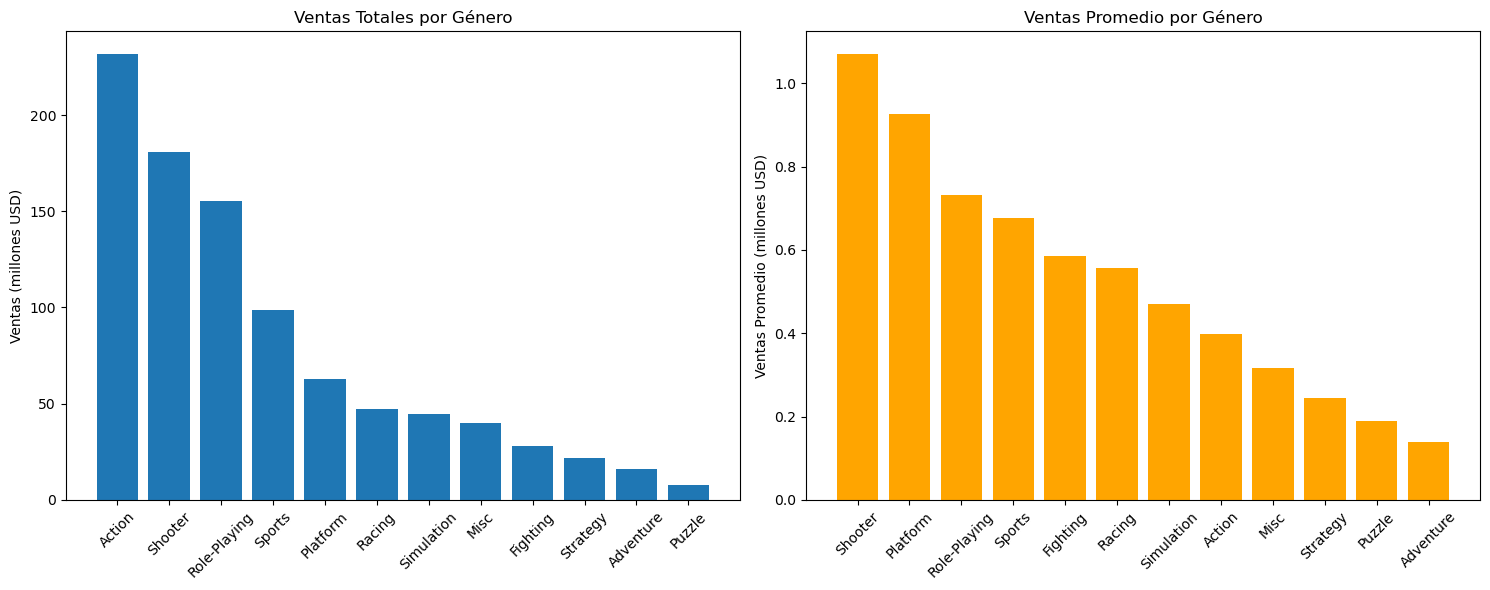

In [28]:
# Crear gráficos comparativos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Ventas totales por género
ax1.bar(ventas_por_genero.index, ventas_por_genero.values)
ax1.set_title('Ventas Totales por Género')
ax1.set_ylabel('Ventas (millones USD)')
ax1.tick_params(axis='x', rotation=45)

# Ventas promedio por género
ventas_promedio_genero = df_projection.groupby('genre')['total_sales'].mean().sort_values(ascending=False)
ax2.bar(ventas_promedio_genero.index, ventas_promedio_genero.values, color='orange')
ax2.set_title('Ventas Promedio por Género')
ax2.set_ylabel('Ventas Promedio (millones USD)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Los tres géneros más rentables en cuanto a cantidad total de de ventas son Action, Shooter y Role-playing ordenados de forma ascendente respectivamente. Sin embargo si el estudio lo planteamos en base a las ventas promedio la cosa cambia, el género con mayor promedio de venta por juego es Shooter seguido de Role-playing y por último Action. En cuanto a la desviación estándar la menor es para el género de Action seguido de Role-playing y por útlimo Shooter. A mi parecer los datos más importantes serían la media de ventas alta de género y que tenga una desviación estándar baja ya que significa que habrá menos variación entre la media de las ventas, por otro lado este análsis mediante la media se puede comprobar con el coeficiente de variación, el cuál indica que un CV bajo (ej. <0.3) sugiere datos más homogéneos y consistentes, mientras que un CV alto indica mayor dispersión y heterogeneidad, haciendo que la media sea menos representativa. Para todos los géneros este coeficiente es mayor a uno lo que suguiere no usar la media ya que no es un parámetro que sea represtativo para las ventas de acuerdo al género.

## Paso 4. Crea un perfil de usuario para cada región
Para cada región (NA, UE, JP) determina:

- Las cinco plataformas principales. Describe las variaciones en sus cuotas de mercado de una región a otra.
- Los cinco géneros principales. Explica la diferencia.
- Si las clasificaciones de ESRB afectan a las ventas en regiones individuales.

In [29]:
# Análisis de plataformas por región
print("=== ANÁLISIS DE PLATAFORMAS POR REGIÓN ===\n")

# Norteamérica (NA)
top_platforms_na = df_projection.groupby('platform')['na_sales'].sum().sort_values(ascending=False)
print("Top 5 plataformas en Norteamérica:")
print(top_platforms_na.head())

# Europa (EU)
top_platforms_eu = df_projection.groupby('platform')['eu_sales'].sum().sort_values(ascending=False)
print("\nTop 5 plataformas en Europa:")
print(top_platforms_eu.head())

# Japón (JP)
top_platforms_jp = df_projection.groupby('platform')['jp_sales'].sum().sort_values(ascending=False)
print("\nTop 5 plataformas en Japón:")
print(top_platforms_jp.head())

=== ANÁLISIS DE PLATAFORMAS POR REGIÓN ===

Top 5 plataformas en Norteamérica:
platform
PS4     108.74
XOne     93.12
3DS      82.65
PC       39.07
WiiU     38.10
Name: na_sales, dtype: float64

Top 5 plataformas en Europa:
platform
PS4     141.09
PC       68.82
3DS      61.27
XOne     51.59
WiiU     25.13
Name: eu_sales, dtype: float64

Top 5 plataformas en Japón:
platform
3DS     100.62
PS4      15.96
WiiU     13.01
XOne      0.34
PC        0.00
Name: jp_sales, dtype: float64


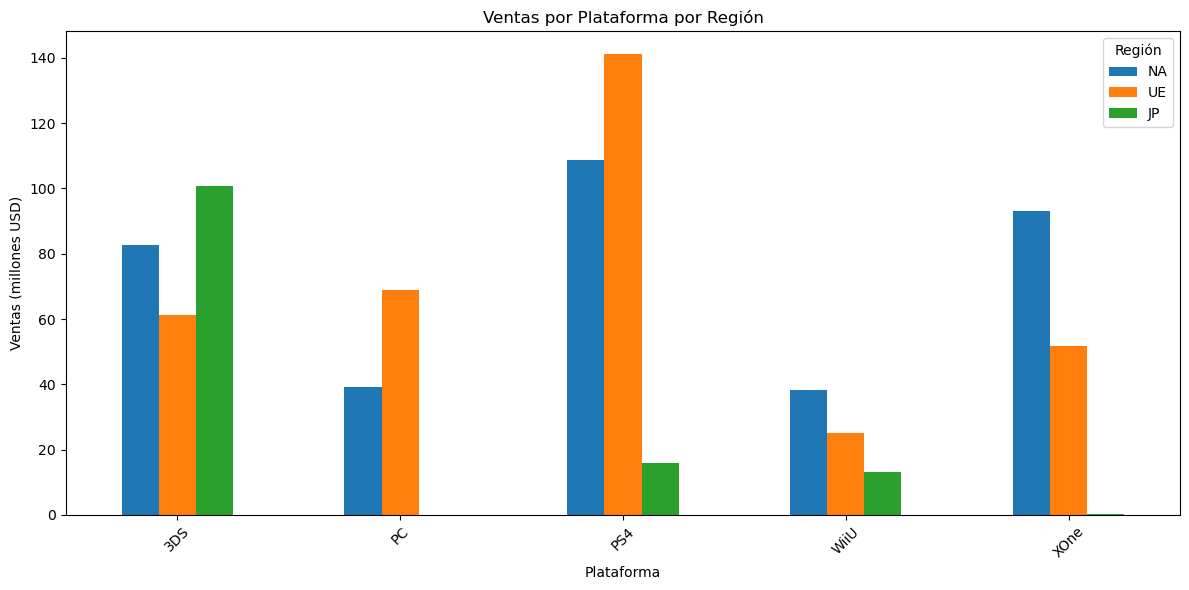


Comparación de cuotas de mercado:
              NA      UE      JP
platform                        
3DS        82.65   61.27  100.62
PC         39.07   68.82    0.00
PS4       108.74  141.09   15.96
WiiU       38.10   25.13   13.01
XOne       93.12   51.59    0.34


In [30]:
# Crear DataFrame comparativo
comparison_platforms = pd.DataFrame({
    'NA': top_platforms_na,
    'UE': top_platforms_eu, 
    'JP': top_platforms_jp
}).fillna(0)

# Gráfico de barras agrupadas
fig, ax = plt.subplots(figsize=(12, 6))
comparison_platforms.plot(kind='bar', ax=ax)
plt.title('Ventas por Plataforma por Región')
plt.ylabel('Ventas (millones USD)')
plt.xlabel('Plataforma')
plt.legend(title='Región')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nComparación de cuotas de mercado:")
print(comparison_platforms)

In [31]:
# Análisis de género por región
print("=== ANÁLISIS DE GÉNERO POR REGIÓN ===\n")

# Norteamérica (NA)
top_genre_na = df_projection.groupby('genre')['na_sales'].sum().sort_values(ascending=False)
print("Top 5 plataformas en Norteamérica:")
print(top_genre_na.head())

# Europa (EU)
top_genre_eu = df_projection.groupby('genre')['eu_sales'].sum().sort_values(ascending=False)
print("\nTop 5 plataformas en Europa:")
print(top_genre_eu.head())

# Japón (JP)
top_genre_jp = df_projection.groupby('genre')['jp_sales'].sum().sort_values(ascending=False)
print("\nTop 5 plataformas en Japón:")
print(top_genre_jp.head())

=== ANÁLISIS DE GÉNERO POR REGIÓN ===

Top 5 plataformas en Norteamérica:
genre
Action          90.44
Shooter         80.81
Role-Playing    53.23
Sports          38.89
Platform        26.20
Name: na_sales, dtype: float64

Top 5 plataformas en Europa:
genre
Action          86.93
Shooter         72.82
Role-Playing    43.63
Sports          43.47
Racing          21.26
Name: eu_sales, dtype: float64

Top 5 plataformas en Japón:
genre
Role-Playing    46.41
Action          29.70
Platform        10.65
Simulation      10.57
Misc             8.39
Name: jp_sales, dtype: float64


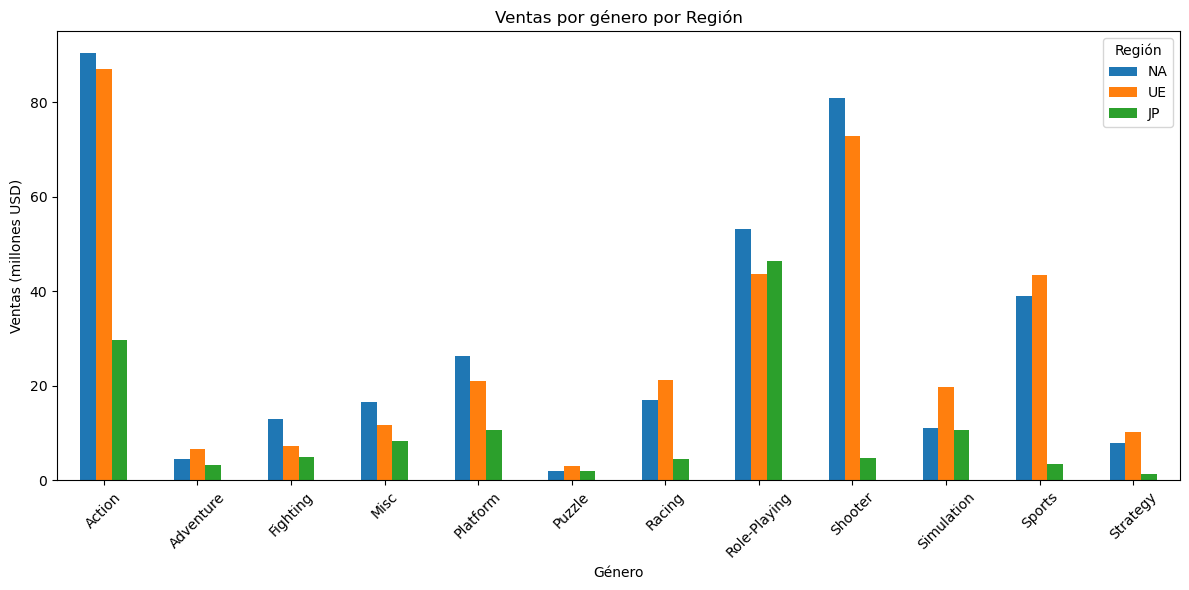


Comparación de cuotas de mercado:
                 NA     UE     JP
genre                            
Action        90.44  86.93  29.70
Adventure      4.58   6.63   3.24
Fighting      13.00   7.33   4.99
Misc          16.59  11.78   8.39
Platform      26.20  21.07  10.65
Puzzle         1.98   3.04   2.02
Racing        17.07  21.26   4.44
Role-Playing  53.23  43.63  46.41
Shooter       80.81  72.82   4.71
Simulation    11.06  19.75  10.57
Sports        38.89  43.47   3.49
Strategy       7.83  10.19   1.32


In [32]:
# Crear DataFrame comparativo
comparison_platforms = pd.DataFrame({
    'NA': top_genre_na,
    'UE': top_genre_eu, 
    'JP': top_genre_jp
}).fillna(0)

# Gráfico de barras agrupadas
fig, ax = plt.subplots(figsize=(12, 6))
comparison_platforms.plot(kind='bar', ax=ax)
plt.title('Ventas por género por Región')
plt.ylabel('Ventas (millones USD)')
plt.xlabel('Género')
plt.legend(title='Región')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nComparación de cuotas de mercado:")
print(comparison_platforms)

In [33]:
df_esrb = df_projection[df_projection['rating'].notna()]
# print(df_esbr)

# Análisis de clasificaciones ESRB por región
print("=== ANÁLISIS DE CLASIFICACIONES ESRB POR REGIÓN ===\n")
for region in ['na_sales', 'eu_sales', 'jp_sales']:
    print(f"\nVentas totales en {region.upper()}:")
    ventas_esrb = df_esrb.groupby('rating')[region].sum().sort_values(ascending=False)
    print(ventas_esrb.round(3))

print("\n=== VENTAS PROMEDIO POR CLASIFICACIÓN ===")

for region in ['na_sales', 'eu_sales', 'jp_sales']:
    print(f"\nPromedio de ventas en {region.upper()}:")
    promedio_esrb = df_esrb.groupby('rating')[region].mean().sort_values(ascending=False)
    print(promedio_esrb.round(3))

=== ANÁLISIS DE CLASIFICACIONES ESRB POR REGIÓN ===


Ventas totales en NA_SALES:
rating
M       109.79
E        79.48
T        49.84
E10+     44.65
EC        0.09
RP        0.00
Name: na_sales, dtype: float64

Ventas totales en EU_SALES:
rating
M       113.56
E        80.50
T        47.12
E10+     32.63
RP        0.03
EC        0.00
Name: eu_sales, dtype: float64

Ventas totales en JP_SALES:
rating
E       29.34
T       10.46
E10+     7.98
M        7.33
EC       0.00
RP       0.00
Name: jp_sales, dtype: float64

=== VENTAS PROMEDIO POR CLASIFICACIÓN ===

Promedio de ventas en NA_SALES:
rating
M       0.346
E       0.277
E10+    0.199
T       0.169
EC      0.045
RP      0.000
Name: na_sales, dtype: float64

Promedio de ventas en EU_SALES:
rating
M       0.358
E       0.280
T       0.160
E10+    0.146
RP      0.030
EC      0.000
Name: eu_sales, dtype: float64

Promedio de ventas en JP_SALES:
rating
E       0.102
E10+    0.036
T       0.035
M       0.023
EC      0.000
RP      0.000
Name:

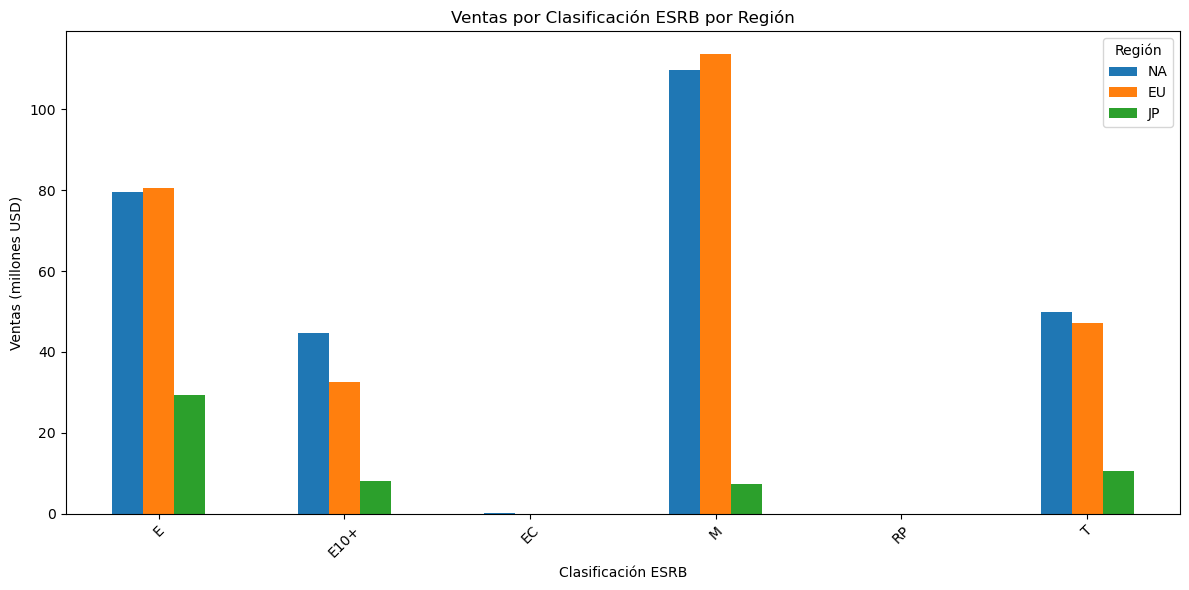

Comparación de ventas por clasificación ESRB:
            NA      EU     JP
rating                       
E        79.48   80.50  29.34
E10+     44.65   32.63   7.98
EC        0.09    0.00   0.00
M       109.79  113.56   7.33
RP        0.00    0.03   0.00
T        49.84   47.12  10.46


In [34]:
# Crear DataFrame comparativo para ESRB
esrb_na = df_esrb.groupby('rating')['na_sales'].sum()
esrb_eu = df_esrb.groupby('rating')['eu_sales'].sum()
esrb_jp = df_esrb.groupby('rating')['jp_sales'].sum()

comparison_esrb = pd.DataFrame({
    'NA': esrb_na,
    'EU': esrb_eu, 
    'JP': esrb_jp
}).fillna(0)

# Gráfico de barras agrupadas
fig, ax = plt.subplots(figsize=(12, 6))
comparison_esrb.plot(kind='bar', ax=ax)
plt.title('Ventas por Clasificación ESRB por Región')
plt.ylabel('Ventas (millones USD)')
plt.xlabel('Clasificación ESRB')
plt.legend(title='Región')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Comparación de ventas por clasificación ESRB:")
print(comparison_esrb.round(2))

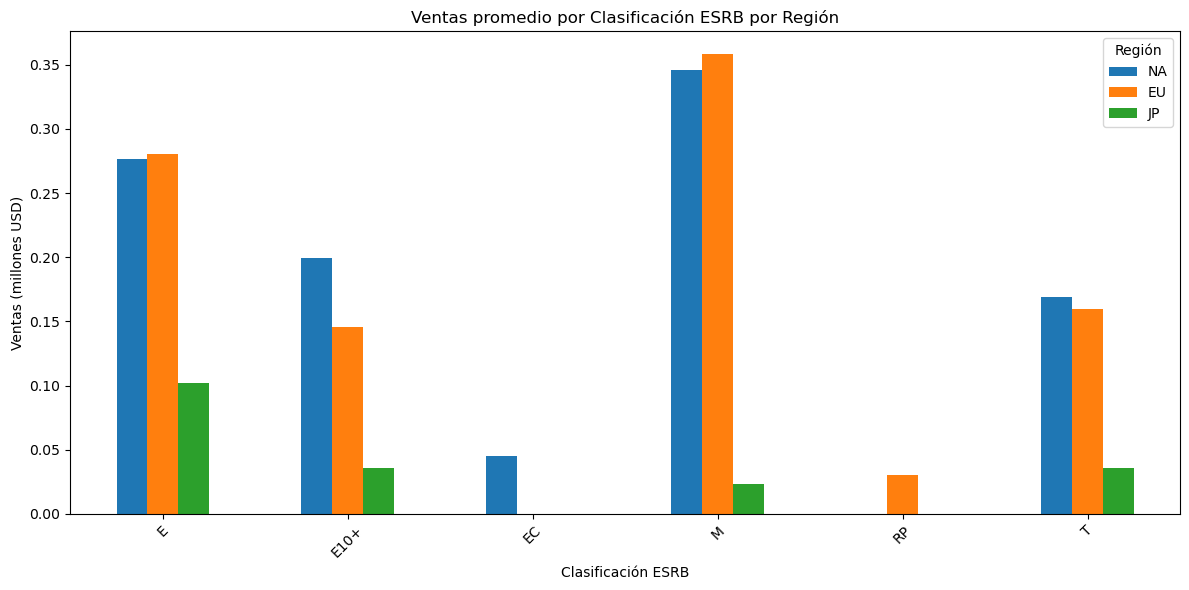

Comparación de ventas promedio por clasificación ESRB:
          NA    EU    JP
rating                  
E       0.28  0.28  0.10
E10+    0.20  0.15  0.04
EC      0.04  0.00  0.00
M       0.35  0.36  0.02
RP      0.00  0.03  0.00
T       0.17  0.16  0.04


In [35]:
# Crear DataFrame comparativo para ESRB
esrb_na = df_esrb.groupby('rating')['na_sales'].mean()
esrb_eu = df_esrb.groupby('rating')['eu_sales'].mean()
esrb_jp = df_esrb.groupby('rating')['jp_sales'].mean()

comparison_esrb = pd.DataFrame({
    'NA': esrb_na,
    'EU': esrb_eu, 
    'JP': esrb_jp
}).fillna(0)

# Gráfico de barras agrupadas
fig, ax = plt.subplots(figsize=(12, 6))
comparison_esrb.plot(kind='bar', ax=ax)
plt.title('Ventas promedio por Clasificación ESRB por Región')
plt.ylabel('Ventas (millones USD)')
plt.xlabel('Clasificación ESRB')
plt.legend(title='Región')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Comparación de ventas promedio por clasificación ESRB:")
print(comparison_esrb.round(2))

Las ventas por región influyen principalmente en el género, la región de Japón es la única que varia significativamente en las ventas y plataformas usadas. En cuanto al análisis por clasificación ESRB  y región no parece haber diferencias significativas entre las regiones de Norteámerica y Europa, donde hay cambios es en la región de Japón.

## Paso 5. Prueba las siguientes hipótesis: ##
- Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.
- Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

Establece tu mismo el valor de umbral alfa.


Explica:

- Cómo formulaste las hipótesis nula y alternativa.
- Qué criterio utilizaste para probar las hipótesis y por qué.

Las calificaciones de usuarios promedio para las plataformas Xbox One y PC son las mismas: \
Ho : las medias de Xbox One y Pc son las mismas.\
Ha : las medias de Xbox One y PC son diferentes.

Prueba de t-Student para dos medias.\
Alfa : 0.05

Para muestras con n>30 (mayor a 30 muestras) se necesita comprobar que ambas poblaciones sigan una distrubución normal y sus varianzas sean significativamente iguales.

In [36]:
xbox_scores = df_projection[(df_projection['platform'] == 'XOne') & 
                           (df_projection['user_score'].notna())]['user_score']

pc_scores = df_projection[(df_projection['platform'] == 'PC') & 
                         (df_projection['user_score'].notna())]['user_score']

# Test de normalidad
_, p_xbox = stats.shapiro(xbox_scores)
_, p_pc = stats.shapiro(pc_scores)
# Para cumplir la prueba de normalidad p valor debe ser mayor o igual a 0.05
print(f"Normalidad Xbox One (p-valor): {p_xbox:.3f}")
print(f"Normalidad PC (p-valor): {p_pc:.3f}")
for p_value, plataforma in zip([p_xbox, p_pc], ['Xbox One', 'PC']):
    if p_value >= 0.05:
        print(f"  -> Los datos de {plataforma} normales parecen seguir una distribución normal ({p_value: 3f} > 0.05)")
    else:
        print(f"  -> Los datos de {plataforma} normales NO parecen seguir una distribución normal ({p_value: 3f} <= 0.05)")
        
# Verificar homogeneidad de varianzas
# Si p valor es menor que 0.05 las varianzas son diferentes
_, p_levene = stats.levene(xbox_scores, pc_scores)
print(f"\nHomogeneidad de varianzas (p-valor): {p_levene:.3f}")
if p_levene > 0.05:
    print(f"  -> Las varianzas son iguales. ({p_levene:.3f} > 0.05)")
else:
    print(f"  -> Las varianzas NO son iguales. ({p_levene:.3f} <= 0.05)")

Normalidad Xbox One (p-valor): 0.000
Normalidad PC (p-valor): 0.000
  -> Los datos de Xbox One normales NO parecen seguir una distribución normal ( 0.000015 <= 0.05)
  -> Los datos de PC normales NO parecen seguir una distribución normal ( 0.000000 <= 0.05)

Homogeneidad de varianzas (p-valor): 0.034
  -> Las varianzas NO son iguales. (0.034 <= 0.05)


Investigando en la web para muestras con una distribución no normal y varianzas desiguales la prueba a realizar es la prueba t de Welch (Welch's t-test), una variante robusta de la t-test que no asume varianzas iguales y es menos sensible a la falta de normalidad. Donde las hipotesis y el alfa siguen siendo iguales.


In [37]:
# Realizar la Prueba t de Welch (equal_var=False)
estadistico_t, p_valor_welch = stats.ttest_ind(xbox_scores, pc_scores, equal_var=False)

print(f"Estadístico t de Welch: {estadistico_t}")
print(f"P-valor de Welch: {p_valor_welch}")

# Interpretación
if p_valor_welch < 0.05:
    print("Se rechaza la hipótesis nula: hay diferencia significativa entre las medias.")
else:
    print("No hay suficiente evidencia para rechazar la hipótesis nula.")

Estadístico t de Welch: 0.024879518331077908
P-valor de Welch: 0.9801634129117883
No hay suficiente evidencia para rechazar la hipótesis nula.


Con la prueba realizada podemos decir con un 95% de certeza que las medias de las críticas de usuarios de Xbox One y PC son iguales.

#### La puntuación promedio de los usuarios de los géneros de acción y deporte son iguales:
Ho: las medias son iguales.

Ha: las medias son diferentes.

Alfa = 0.05

In [38]:
action_scores = df_projection[(df_projection['genre'] == 'Action') & 
                           (df_projection['user_score'].notna())]['user_score']

sports_scores = df_projection[(df_projection['genre'] == 'Sports') & 
                         (df_projection['user_score'].notna())]['user_score']

# Test de normalidad
_, p_action = stats.shapiro(action_scores)
_, p_sports = stats.shapiro(sports_scores)
# Para cumplir la prueba de normalidad p valor debe ser mayor o igual a 0.05
print(f"Normalidad Xbox One (p-valor): {p_action:.3f}")
print(f"Normalidad PC (p-valor): {p_sports:.3f}")
for p_value, genre in zip([p_action, p_sports], ['Action', 'Sports']):
    if p_value >= 0.05:
        print(f"  -> Los datos de {genre} normales parecen seguir una distribución normal ({p_value: 3f} > 0.05)")
    else:
        print(f"  -> Los datos de {genre} normales NO parecen seguir una distribución normal ({p_value: 3f} <= 0.05)")
        
# Verificar homogeneidad de varianzas
# Si p valor es menor que 0.05 las varianzas son diferentes
_, p_levene = stats.levene(action_scores, sports_scores)
print(f"\nHomogeneidad de varianzas (p-valor): {p_levene:.3f}")
if p_levene > 0.05:
    print(f"  -> Las varianzas son iguales. ({p_levene:.3f} > 0.05)")
else:
    print(f"  -> Las varianzas NO son iguales. ({p_levene:.3f} <= 0.05)")

Normalidad Xbox One (p-valor): 0.000
Normalidad PC (p-valor): 0.003
  -> Los datos de Action normales NO parecen seguir una distribución normal ( 0.000000 <= 0.05)
  -> Los datos de Sports normales NO parecen seguir una distribución normal ( 0.003007 <= 0.05)

Homogeneidad de varianzas (p-valor): 0.107
  -> Las varianzas son iguales. (0.107 > 0.05)


Volviendo a investigar en la web encontré la tería del límite central de datos que dice:
Teorema del Límite Central: Con muestras grandes (generalmente (n>30), la distribución muestral de las medias se acerca a una distribución normal, haciendo la prueba t robusta incluso si la población original no lo es.

Por lo que para este caso que las varianzas son iguales podemos hacer una pruba t.

In [39]:
# Prueba t
t_stats, p_valor = stats.ttest_ind(action_scores, sports_scores)
if p_valor > 0.05:
    print(f"  -> No se rechaza la hipótesis nula ({p_valor: 3f} > 0.05).\n"
        "Por lo tanto NO hay suficiente evidencia de una diferencia significativa. ")
else:
    print(f"  -> Se rechaza la hipótesis nula ({p_valor: 3f} < 0.05).\n"
             "Por lo tanto hay evidencia de una diferencia significativa entre las medias.")

  -> Se rechaza la hipótesis nula ( 0.000000 < 0.05).
Por lo tanto hay evidencia de una diferencia significativa entre las medias.


Existe una diferencia significativa entre el promedio de las puntuaciones hechas por usuarios entre los géneros de acción y deportes.

## Paso 6. Escribe una conclusión general


1. Plataformas más prometedoras para 2017:

- PS4 y Xbox One son las plataformas en crecimiento.
- PS4 lidera en ventas totales y promedio por juego.
- 3DS mantiene una posición sólida, especialmente en Japón.

2. Géneros más rentables:

- Action, Shooter y Role-Playing son los géneros con mayores ventas totales.
- Shooter tiene el mayor promedio de ventas por juego.
- La variabilidad es alta en todos los géneros.

3. Diferencias regionales significativas:

- Japón prefiere 3DS y géneros Role-Playing.
- Norteamérica y Europa son similares, prefiriendo PS4/Xbox One.
- Las clasificaciones ESRB afectan diferente según la región.

4. Factores que influyen en las ventas:

- Las puntuaciones de críticos tienen correlación moderada con las ventas (0.404).
- Las puntuaciones de usuarios no muestran correlación clara.
- Los juegos multiplataforma de LEGO tienen buen rendimiento.